In [1]:
import Hamiltonian as ham
import PauliStrings as pauli_strings
import scipy.sparse as sp
import numpy as np
from matplotlib import pyplot as plt
import Evolution_sim as evol

In [2]:
def fidelity_pure(psi,phi):
    '''
    input values should be column vectors
    '''
    F=np.abs(psi.conj().T@phi)**2
    return F[0,0]

def variance(psi,H):
    V=np.real((psi.conj().T@H@H@psi)-(psi.conj().T@H@psi)**2)
    return V[0,0]


In [3]:
#Hamiltonian Params Traverse Field Ising model
n_qubits=8
J=1
h=0.5
T=2

#trotter params
H,H_trot=ham.TFIM(J,h,n_qubits,T=T)
print('Computing Eigs')
EH,VH = np.linalg.eigh(H.todense())
psigs=VH[:,0]
E_gs=EH[0]

#evolution parameters
dt=0.1
N=100
tmax=dt*N
t=0 + np.arange(0, N+1) *dt

#initial state
psi0np=np.zeros((2**n_qubits,1),dtype=complex)
psi0np[0]=1
psi_0=sp.csc_matrix(psi0np/np.linalg.norm(psi0np))
#psi_0=sp.csc_matrix(psirand(2**n_qubits).data).T

#QITE and ITE evolution
D=4
NQ=20
print("Computing QITE")
EQ,psi_QITE,a = evol.QITE(n_qubits,H,H_trot,D,psi_0,NQ,dt)
E_ACQ,psi_ACQ,indx = evol.ACQ(n_qubits,H,H_trot,D,psi_0,N,dt,methodLS='LU')

#Fidelities and var
var_ACQ=np.zeros(N+1)
F_ACQ=np.zeros(N+1)
F1=np.zeros(N+1)
for i in range(N+1):
    F_ACQ[i]=fidelity_pure(psigs,psi_ACQ[:,i].todense())
    F1[i]=fidelity_pure(VH[:,1],psi_ACQ[:,i].todense())
    var_ACQ[i]=variance(psi_ACQ[:,i],H)

#Fidelities QITE and var
NQ=len(EQ)
var_Q=np.zeros(NQ)
F_Q=np.zeros(NQ)
F_1Q=np.zeros(NQ)
for i in range(NQ):
    F_Q[i]=fidelity_pure(psigs,psi_QITE[:,i].todense())
    F_1Q[i]=fidelity_pure(VH[:,1],psi_QITE[:,i].todense())
    var_Q[i]=variance(psi_QITE[:,i],H)

Computing Eigs
Computing QITE
Energy doubly increased at step 16
Using Real Pauli Strings
Computing U at step 0
Computing U at step 15
Computing U at step 18
Computing U at step 22
Computing U at step 26
Computing U at step 29
Computing U at step 32
Computing U at step 33
Energy doubly increased, stopping criteria activated at step 34


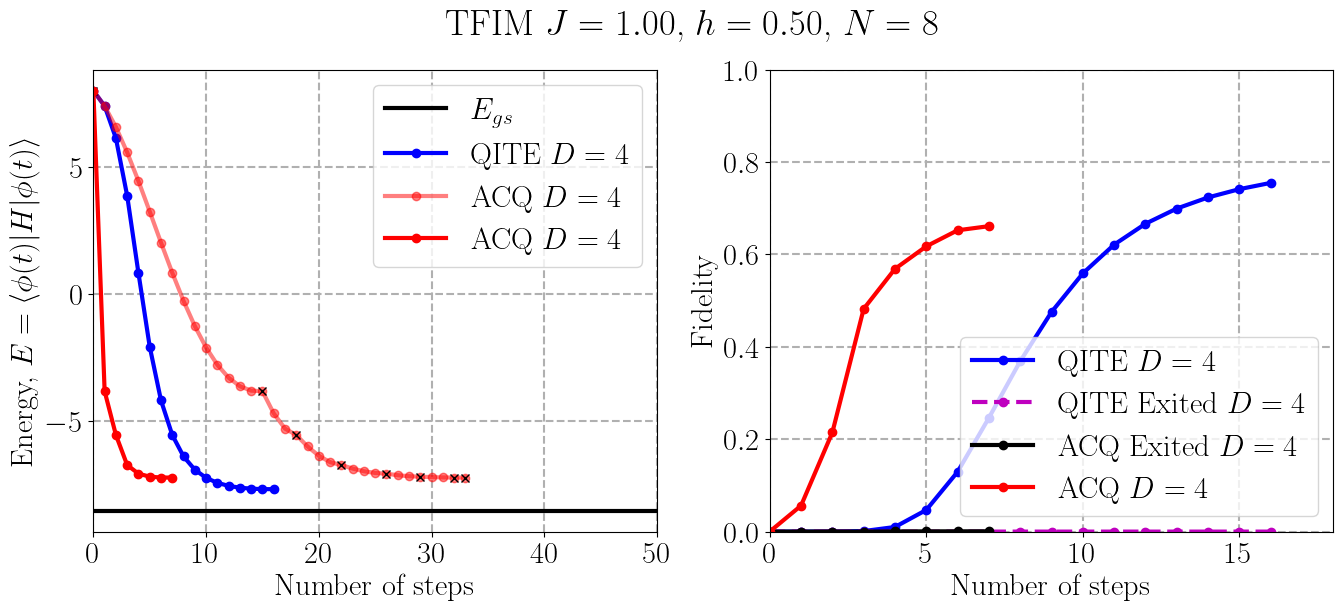

In [4]:
plt.figure(figsize=(16, 6))
plt.rcParams.update({
    "text.usetex": True,
})
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 22}

plt.rc('font', **font)
plt.suptitle("TFIM $J=%.2f$, $h=%.2f$, $N=%d$"%(J,h,n_qubits))
t=np.arange(N)
plt.subplot(1,2,1)
plt.plot(t,t*0+EH[0],'-k',linewidth=3,label='$E_{gs}$')
plt.plot(t[0:NQ],EQ,'-bo',linewidth=3,label='QITE $D=%d$'%D)
plt.plot(t[0:indx[-1]+1],E_ACQ[0:indx[-1]+1],'-ro',linewidth=3,label='ACQ $D=%d$'%D,alpha=0.5)
plt.plot(t[indx],E_ACQ[indx],'kx',linewidth=3)
plt.plot(t[0:len(indx)],E_ACQ[indx],'-ro',linewidth=3,label='ACQ $D=%d$'%D)
plt.xlabel("Number of steps")
plt.ylabel("Energy, $E=\\langle \\phi(t)|H|\\phi(t)\\rangle$")
plt.xlim(0, 50)
#plt.yticks(np.arange(-12, 10, step=4))
plt.legend()
plt.grid(linestyle = '--', linewidth = 1.5)


plt.subplot(1,2,2)
plt.plot(t[0:NQ],F_Q,'-bo',linewidth=3,label='QITE $D=%d$'%D)
plt.plot(t[0:NQ],F_1Q,'--mo',linewidth=3,label='QITE Exited $D=%d$'%D)
plt.plot(t[0:len(indx)],F1[indx],'-ko',linewidth=3,label='ACQ Exited $D=%d$'%D)
plt.plot(t[0:len(indx)],F_ACQ[indx],'-ro',linewidth=3,label='ACQ $D=%d$'%D)
plt.xlabel("Number of steps")
plt.ylabel("Fidelity")
plt.xlim(0, (NQ+1))
plt.ylim(0,1)
plt.legend()
plt.grid(linestyle = '--', linewidth = 1.5)


#plt.savefig("adaptive_QITE_N12D4.png")